# Astrometric field measurement on joint-canonical anchors (current era)

**This is the current-era astrometry field notebook** (2026-06-12). It supersedes the field-fitting
analyses in notebooks 08/09 (which remain as annotated historical records of the v10-era audit).

What changed (full story in DOCUMENTATION.md):
1. **Anchors**: `models/checkpoints/anchors_joint_canonical_790.npz` — per-band offsets measured against the
   **joint 10-band canonical position** (truth-validated 2.4-2.5x better than VIS-only), with per-band and
   per-source σ columns. 707,850 anchors, 790 tiles.
2. **Fitting practice**: dense anchors (no dedup), every PINN fit has a run-to-run repeat, solver comparisons
   only at ≥150" smoothing. Result: fits reproduce to 0.5-0.9 mas (was ~2-3); HGP-PINN agree at 1.0-1.6 mas.
3. **Decomposition**: the common field component is absorbed by the joint canonical → per-band fields are
   band-specific deviations (Rubin ~2 mas, NISP ~5 mas); the common component is measured against Gaia.

Products loaded here are precomputed in `models/checkpoints/joint_field_products/` (PINN: all/repeat/faint/
bright/split-halves; HGP super-tight). Verdict tables: `_nb09_outputs/joint_field_gate_verdict.txt`,
`_nb09_outputs/gaia_absolute_check.txt`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import gaussian_filter
from pathlib import Path

ROOT = Path('..').resolve() if Path.cwd().name == 'io' else Path('.').resolve()
PROD = ROOT / 'models/checkpoints/joint_field_products'
H = {k: fits.open(PROD / f'{v}.fits') for k, v in {
    'all': 'pinn_joint_all', 'all2': 'pinn_joint_all2', 'faint': 'pinn_joint_faint',
    'bright': 'pinn_joint_bright', 'h1': 'pinn_joint_faint_h1', 'h2': 'pinn_joint_faint_h2',
    'hgp': 'hgp_joint_supertight'}.items()}
ref = H['all']; wref = WCS(ref[1].header)
ny, nx = ref[1].data.shape
support = ref['COVERAGE'].data < 30.0
yy, xx = np.mgrid[0:ny, 0:nx]
ra_g, dec_g = wref.pixel_to_world_values(xx, yy)

def field(h, band, comp, smooth=150.0):
    name = f'{band}.{comp}'
    if name not in [x.name for x in h]: return None
    w = WCS(h[name].header)
    scale = abs(w.pixel_scale_matrix[1, 1]) * 3600
    img = gaussian_filter(np.nan_to_num(h[name].data), smooth / scale)
    px, py = w.world_to_pixel_values(ra_g, dec_g)
    pxi = np.clip(np.round(px).astype(int), 0, h[name].data.shape[1] - 1)
    pyi = np.clip(np.round(py).astype(int), 0, h[name].data.shape[0] - 1)
    return img[pyi, pxi] * 1000

def cmp(a, b, band, smooth=150.0):
    ara, ade = field(H[a], band, 'DRA', smooth), field(H[a], band, 'DDE', smooth)
    bra, bde = field(H[b], band, 'DRA', smooth), field(H[b], band, 'DDE', smooth)
    m = support
    return (np.sqrt(np.mean(ara[m]**2 + ade[m]**2)), np.sqrt(np.mean(bra[m]**2 + bde[m]**2)),
            np.sqrt(np.mean((ara[m]-bra[m])**2 + (ade[m]-bde[m])**2)),
            np.corrcoef(np.concatenate([ara[m], ade[m]]), np.concatenate([bra[m], bde[m]]))[0, 1])

BANDS = ['G', 'R', 'I', 'Z', 'NISP_Y', 'NISP_J', 'NISP_H']
print('loaded', list(H))

loaded ['all', 'all2', 'faint', 'bright', 'h1', 'h2', 'hgp']


## 1. The current per-band fields (150" smoothed)

NISP keeps a coherent ~5 mas group field; Rubin bands are calibrated to ~2 mas relative to the joint
canonical (their common term migrated into the canonical positions).

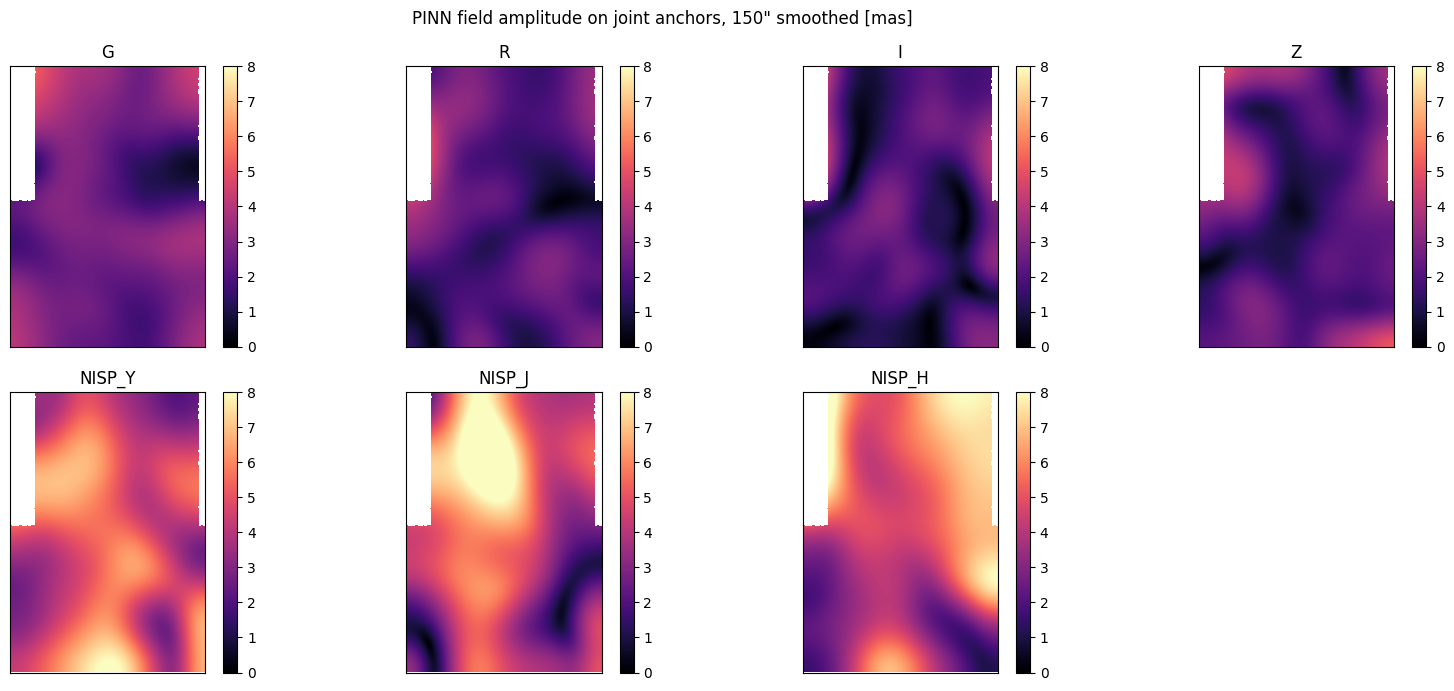

In [2]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, band in zip(axes.ravel(), BANDS):
    amp = np.hypot(field(H['all'], band, 'DRA'), field(H['all'], band, 'DDE'))
    amp[~support] = np.nan
    im = ax.imshow(amp, origin='lower', vmin=0, vmax=8, cmap='magma')
    ax.set_title(band); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
axes.ravel()[-1].axis('off')
fig.suptitle('PINN field amplitude on joint anchors, 150\" smoothed [mas]')
fig.tight_layout(); plt.show()

## 2. Reproducibility and solver agreement (the apparatus checks)

In [3]:
print(f"{'band':8s} | {'run-to-run diff/r':>20s} | {'HGP-PINN diff/r':>18s} | {'faint h1-h2 diff/r':>19s}")
for band in BANDS:
    rr = cmp('all', 'all2', band); hp = cmp('hgp', 'all', band); sh = cmp('h1', 'h2', band)
    print(f'{band:8s} | {rr[2]:7.2f} mas {rr[3]:+.3f} | {hp[2]:6.2f} mas {hp[3]:+.3f} | {sh[2]:6.2f} mas {sh[3]:+.3f}')

band     |    run-to-run diff/r |    HGP-PINN diff/r |  faint h1-h2 diff/r


G        |    0.79 mas +0.965 |   1.09 mas +0.926 |   2.70 mas +0.860


R        |    0.74 mas +0.931 |   1.06 mas +0.879 |   3.55 mas +0.463


I        |    0.87 mas +0.857 |   1.40 mas +0.543 |   3.72 mas +0.289


Z        |    0.91 mas +0.899 |   1.63 mas +0.798 |   5.05 mas +0.114


NISP_Y   |    0.53 mas +0.985 |   1.16 mas +0.937 |   3.01 mas +0.772


NISP_J   |    0.59 mas +0.983 |   0.99 mas +0.956 |   3.32 mas +0.646


NISP_H   |    0.80 mas +0.972 |   1.14 mas +0.952 |   2.74 mas +0.712


## 3. The faint-anchor gate (split-half) and bright/faint comparison

Faint-only (SNR<10) anchors split in half and fit independently: g and NISP pass (r=0.65-0.86 on ~5 mas
fields). Rubin r/i/z halves are noise-dominated because only ~2 mas of band-specific signal remains there.

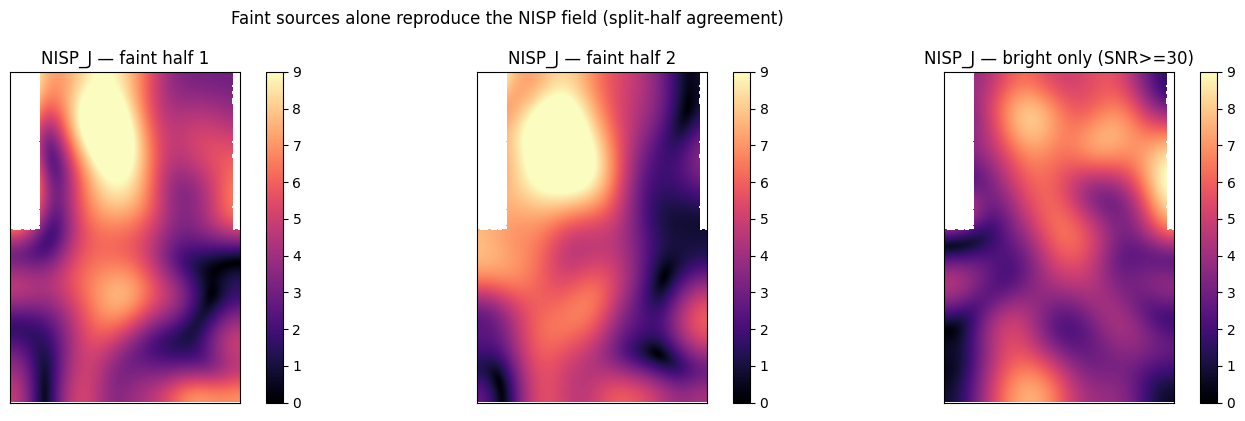

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
band = 'NISP_J'
for ax, (tag, ttl) in zip(axes, [('h1', 'faint half 1'), ('h2', 'faint half 2'), ('bright', 'bright only (SNR>=30)')]):
    amp = np.hypot(field(H[tag], band, 'DRA'), field(H[tag], band, 'DDE'))
    amp[~support] = np.nan
    im = ax.imshow(amp, origin='lower', vmin=0, vmax=9, cmap='magma')
    ax.set_title(f'{band} — {ttl}'); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Faint sources alone reproduce the NISP field (split-half agreement)')
fig.tight_layout(); plt.show()

## 4. Gaia absolute check (the common component)

The component the joint canonical absorbed is measured against Gaia DR3 (PM-propagated to 2025.0):
frame tie (+3.7, +1.9) mas; per-star absolute accuracy 4.4-4.8 mas at G 14-18.5; coherent ±2-4 mas
quadrant structure = the common/absolute field. Full table: `_nb09_outputs/gaia_absolute_check.txt`.

In [5]:
print(open(ROOT / 'io/_nb09_outputs/gaia_absolute_check.txt').read())

Gaia stars: 543; matched to canonical sources within 0.3": 293

bulk (canonical frame vs Gaia ICRS 2025.0): (+3.7, +1.9) mas
per-star scatter after bulk removal: radial median 5.4 mas
G 14.0-17.0: N=  43 bulk (  +3.8,  +2.8) scatter   4.8 mas
G 17.0-18.5: N=  72 bulk (  +4.2,  +2.4) scatter   4.4 mas
G 18.5-20.0: N= 122 bulk (  +3.5,  +1.4) scatter   5.7 mas
G 20.0-21.0: N=  56 bulk (  +3.1,  +0.3) scatter   9.2 mas

bulk offset per sky quadrant (common/absolute component spatial structure):
( +2.7, +1.8)N= 22  ( +2.3, +2.2)N= 16  ( +3.9, +1.0)N= 18  ( +2.9, +4.4)N= 17
( +5.7, +2.3)N= 20  ( +3.6, +2.7)N= 11  ( +2.9, +1.0)N= 18  ( +1.9, +6.0)N= 24
( +4.6, -0.4)N= 18  ( +3.9, +3.0)N= 24  ( +3.1, +3.3)N= 17  ( +2.6, +2.1)N= 14
( +4.3, +1.6)N= 13  ( +4.7, +2.8)N= 22  ( +4.3, -1.5)N= 20  ( +3.8, +0.5)N= 19

